## Part 2: Exploratory Data Analysis (EDA)
In this section we’ll cover:
1. EDA Setup  
2. Initial Data Inspection  
3. Univariate Analysis  
4. Bivariate Analysis  
5. Box Plots  
6. Outlier Treatment Methods

### 1. EDA Setup
- Import libraries  
- Load cleaned dataset  
- Suppress warnings 

In [26]:
# !pip install matplotlib
# !pip install seaborn

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [28]:
df = pd.read_csv(r'../Data/insurance_cleaned.csv')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded: 1337 rows, 9 columns


### 2. Initial Data Inspection
- View first few rows (`head()`)  
- Get dataset shape (`shape`)  
- Get info (`info()`)  
- Summary statistics (`describe()`)

In [29]:
# First rows
df.head()

,age,sex,bmi,children,smoker,region,charges,age_group,bmi_category
0,19,female,27.900,0,yes,southwest,16884.92400,18-30,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,<18,Obese
2,28,male,33.000,3,no,southeast,4449.46200,18-30,Obese
3,33,male,22.705,0,no,northwest,21984.47061,31-45,Normal
4,32,male,28.880,0,no,northwest,3866.85520,31-45,Overweight


In [30]:
print("Shape:", df.shape, '\n')

Shape: (1337, 9) 



In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           1337 non-null   int64  
 1   sex           1337 non-null   object 
 2   bmi           1337 non-null   float64
 3   children      1337 non-null   int64  
 4   smoker        1337 non-null   object 
 5   region        1337 non-null   object 
 6   charges       1337 non-null   float64
 7   age_group     1337 non-null   object 
 8   bmi_category  1337 non-null   object 
dtypes: float64(2), int64(2), object(5)
memory usage: 94.1+ KB


In [32]:
df.describe(include='all')

,age,sex,bmi,children,smoker,region,charges,age_group,bmi_category
count,1337.000000,1337,1337.000000,1337.000000,1337,1337,1337.000000,1337,1337
unique,NaN,2,NaN,NaN,2,4,NaN,5,4
top,NaN,male,NaN,NaN,no,southeast,NaN,46-60,Obese
freq,NaN,675,NaN,NaN,1063,364,NaN,409,715
mean,39.222139,NaN,30.663452,1.095737,NaN,NaN,13279.121487,NaN,NaN
std,14.044333,NaN,6.100468,1.205571,NaN,NaN,12110.359656,NaN,NaN
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900,NaN,NaN
25%,27.000000,NaN,26.290000,0.000000,NaN,NaN,4746.344000,NaN,NaN
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9386.161300,NaN,NaN
75%,51.000000,NaN,34.700000,2.000000,NaN,NaN,16657.717450,NaN,NaN


### 3. Univariate Analysis
- Numeric features: histplot + skewness  
- Categorical features: countplot  
- Log-transform skewed variable (`charges_log`) and re-plot  

age skewness: 0.05


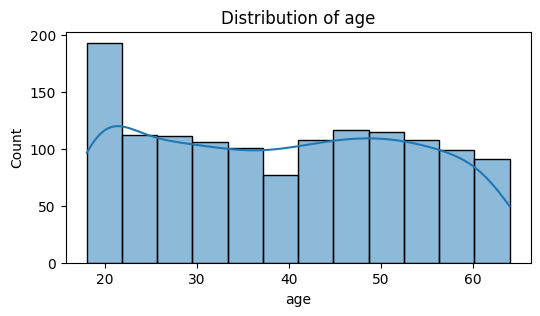

bmi skewness: 0.28


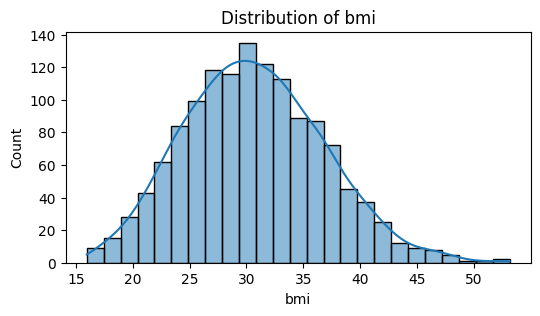

children skewness: 0.94


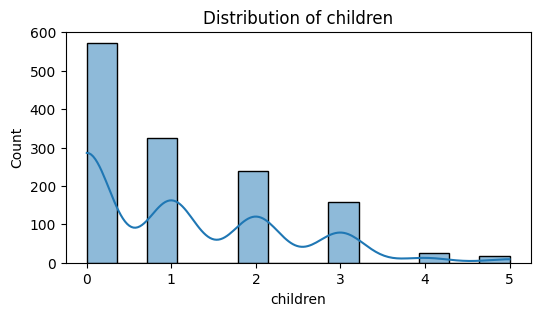

charges skewness: 1.52


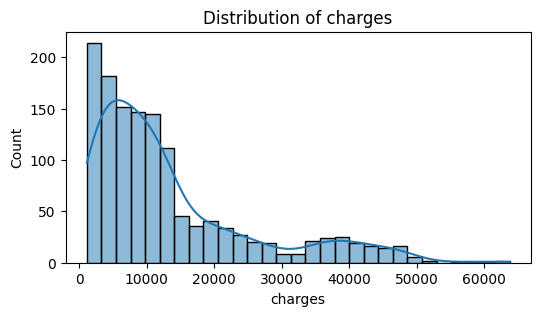

In [33]:
# Numeric variables
numeric_cols = ['age', 'bmi', 'children', 'charges']
for col in numeric_cols:
    print(f"{col} skewness: {df[col].skew():.2f}")
    plt.figure(figsize=(6, 3))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

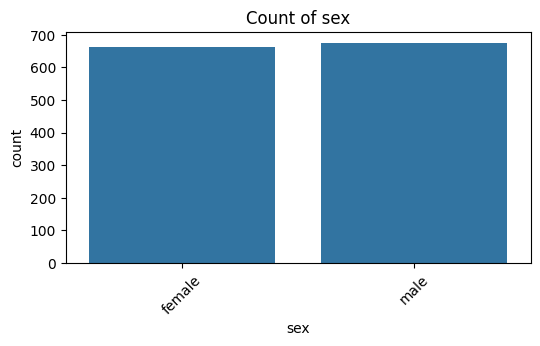

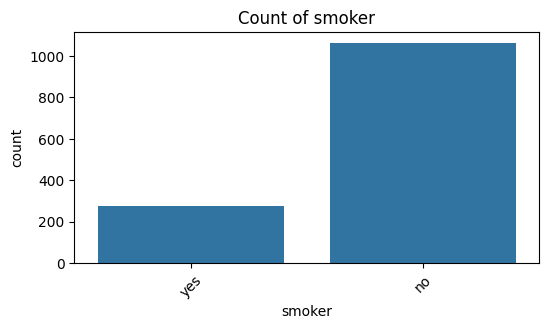

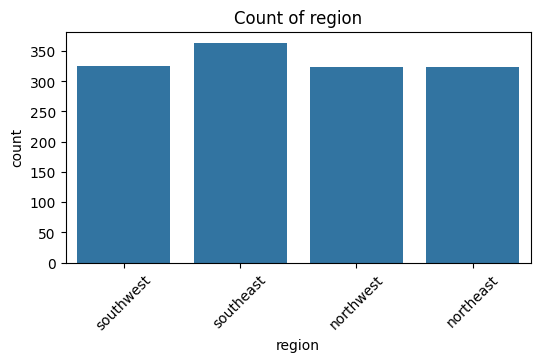

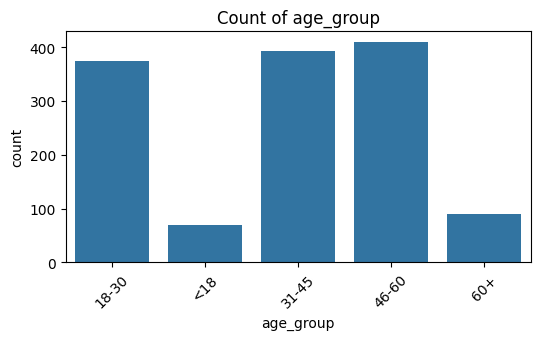

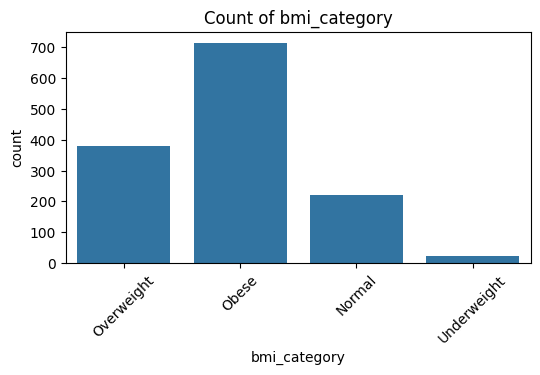

In [34]:
# Categorical variables
categorical_cols = ['sex', 'smoker', 'region', 'age_group', 'bmi_category']
for col in categorical_cols:
    plt.figure(figsize=(6, 3))
    sns.countplot(x=col, data=df)
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)
    plt.show()

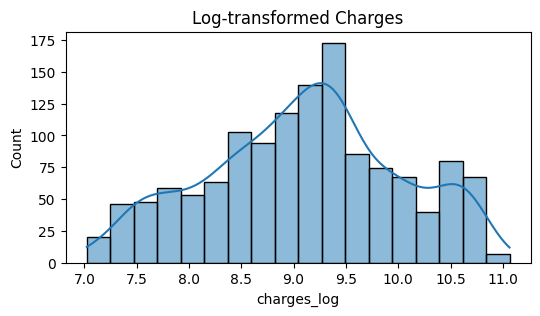

In [35]:
# Log-transform on charges beacuse charge is highly right-skewed
df['charges_log'] = np.log1p(df['charges'])
plt.figure(figsize=(6, 3))
sns.histplot(df['charges_log'], kde=True)
plt.title('Log-transformed Charges')
plt.show()

### 4. Bivariate Analysis
- Pairplot  
- Correlation matrix heatmap  
- Scatter plots: `age` vs `charges`, `bmi` vs `charges`

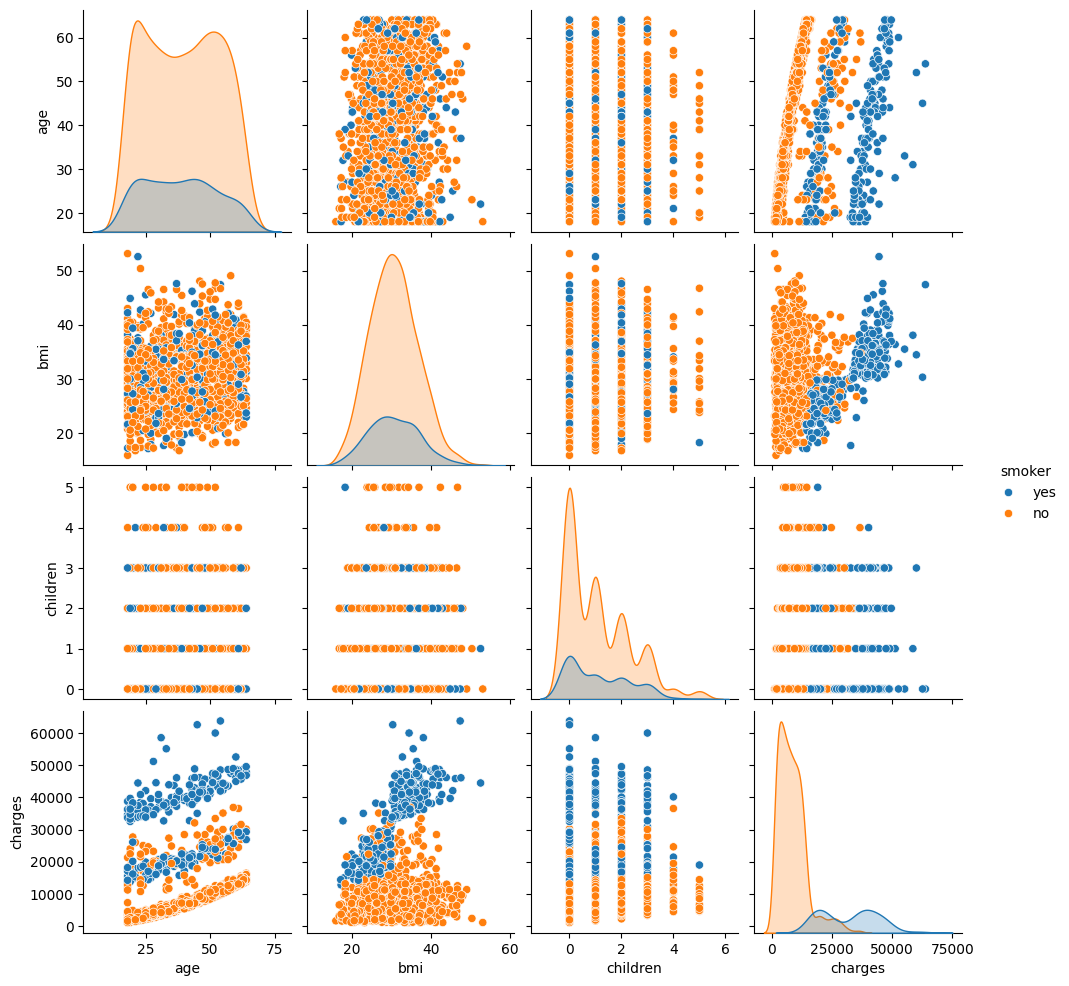

In [36]:
# Pairplot (colored by smoker status)
sns.pairplot(df[['age','bmi','children','charges','smoker']], hue='smoker')
plt.show()

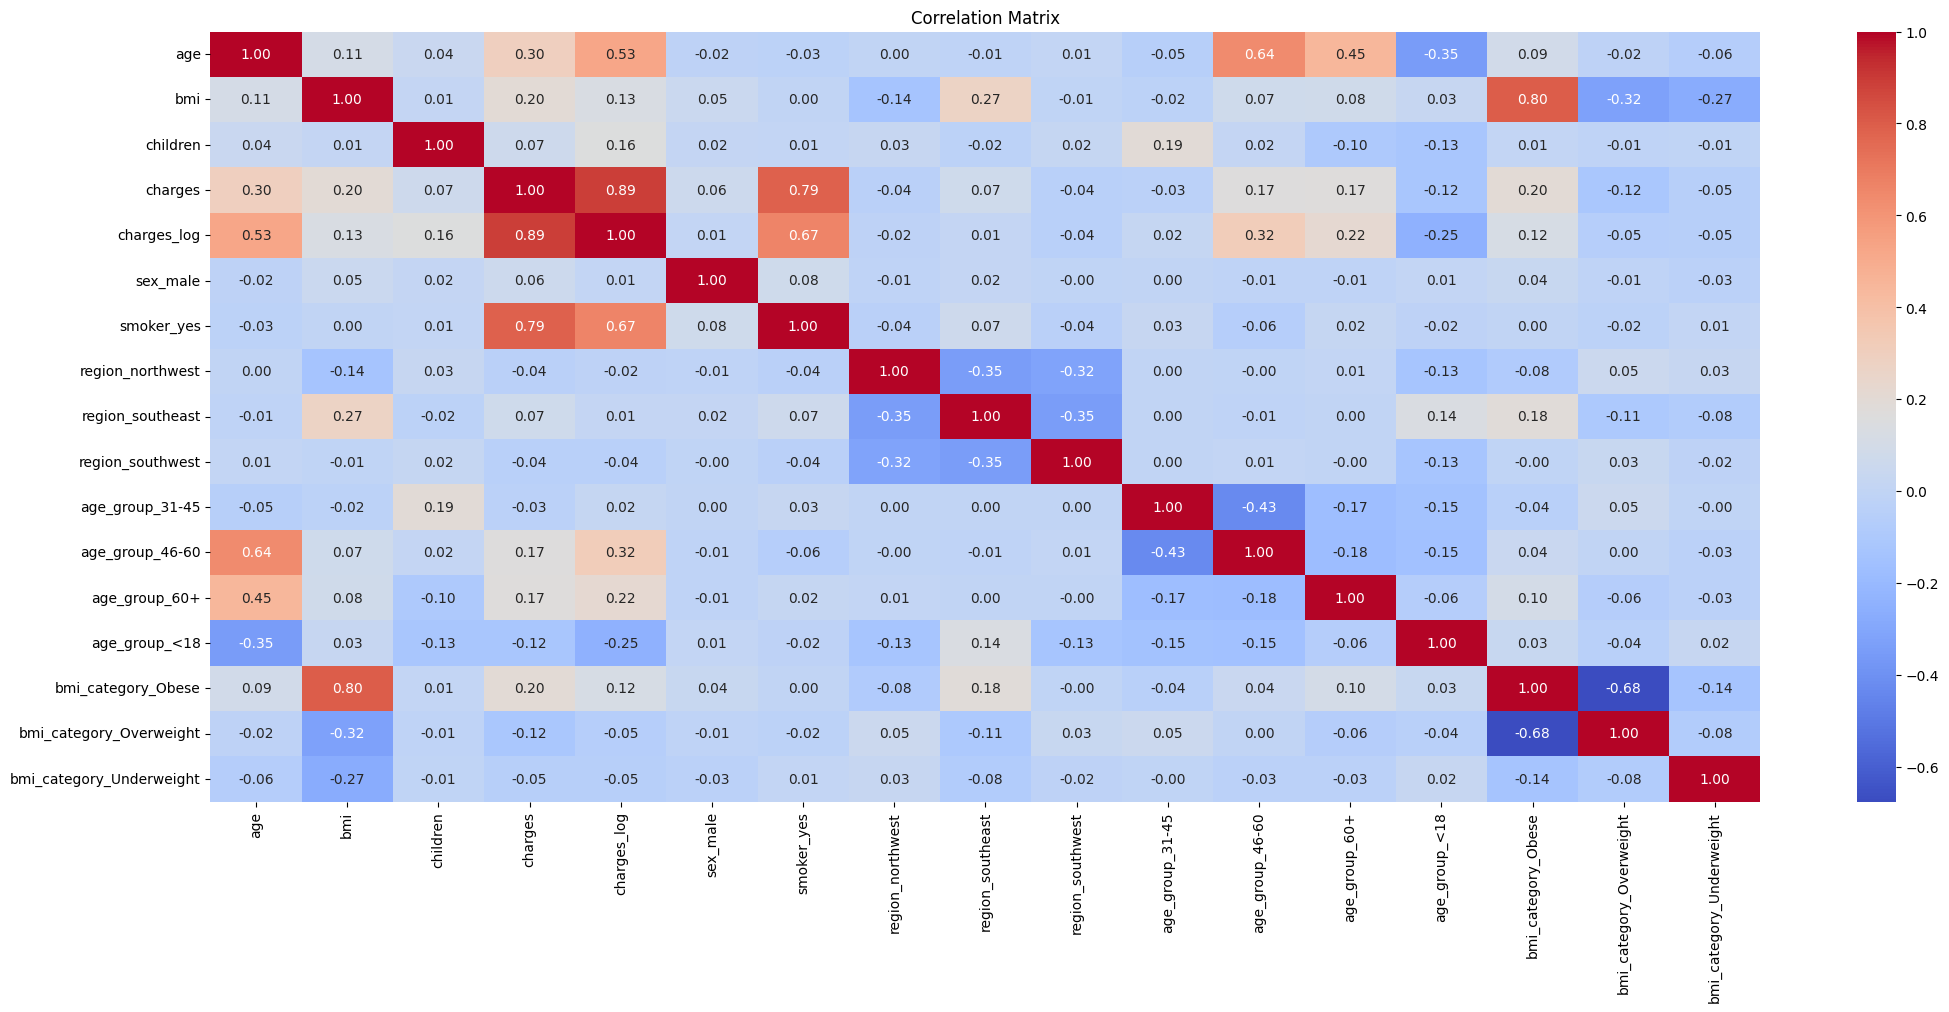

In [37]:
# Correlation heatmap (on numeric+encoded columns)
plt.figure(figsize=(25, 10))
corr = pd.get_dummies(df, drop_first=True).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix') 
plt.show()

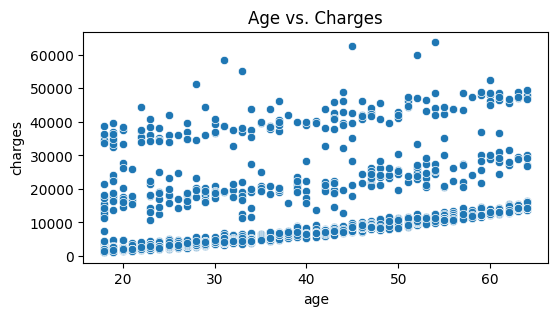

In [38]:
# Scatterplots
plt.figure(figsize=(6, 3))
sns.scatterplot(x='age', y='charges', data=df)
plt.title('Age vs. Charges')
plt.show()

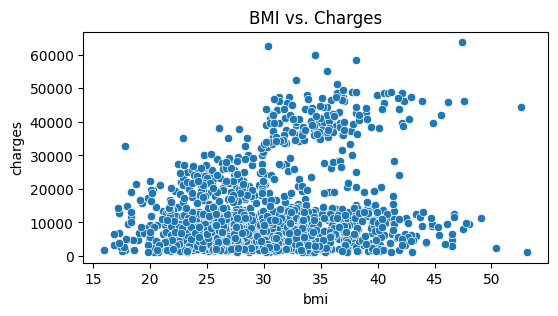

In [39]:
plt.figure(figsize=(6, 3))
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title('BMI vs. Charges')
plt.show()


### 5. Box Plots
- Boxplot for `age`  
- Boxplot for `bmi`  
- Boxplot for `charges`

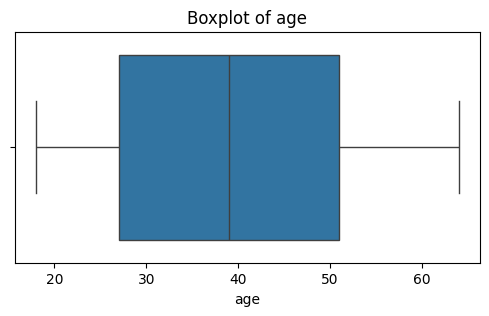

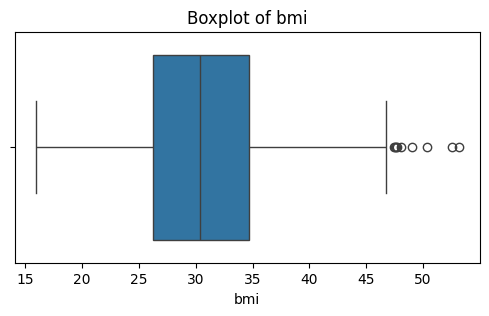

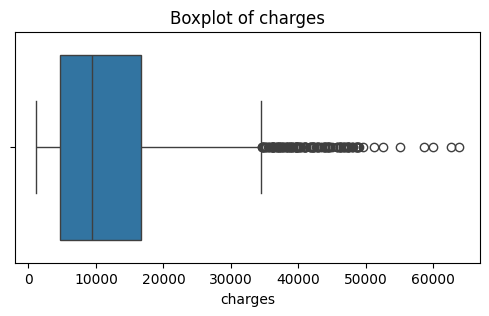

In [40]:
for col in ['age', 'bmi', 'charges']:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

### 6. Outlier Treatment Methods
#### 6.1 Removal (IQR method)
- Identify bounds via IQR  
- Filter data  

In [41]:
# IQR filtering on charges
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)
IQR = Q3 - Q1
df_iqr = df[df['charges'].between(Q1 - 1.5*IQR, Q3 + 1.5*IQR)]
print("Shape after IQR removal:", df_iqr.shape)

Shape after IQR removal: (1198, 10)


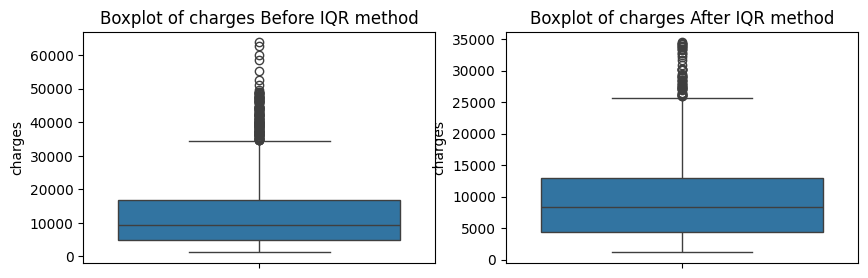

In [42]:
# Visualization of box plot before and after outlier treatment
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
sns.boxplot(data=df["charges"])
plt.title('Boxplot of charges Before IQR method')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_iqr["charges"])
plt.title('Boxplot of charges After IQR method')
plt.show()

#### 6.2 Capping
- Cap `bmi` at 1st and 99th percentiles 

In [43]:
low_bmi, high_bmi = df['bmi'].quantile([0.01, 0.99])
df['bmi_capped'] = df['bmi'].clip(low_bmi, high_bmi)
print(df['bmi_capped'].describe())

count    1337.000000
mean       30.649787
std         6.027430
min        17.894200
25%        26.290000
50%        30.400000
75%        34.700000
max        46.411200
Name: bmi_capped, dtype: float64


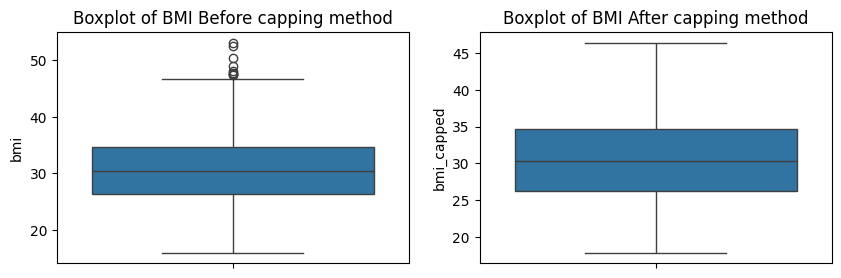

In [44]:
# Visualization of box plot before and after outlier treatment
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
sns.boxplot(data=df["bmi"])
plt.title('Boxplot of BMI Before capping method')

plt.subplot(1, 2, 2)
sns.boxplot(data=df['bmi_capped'])
plt.title('Boxplot of BMI After capping method')
plt.show()

#### 6.3 Transformation
- Apply `log1p` to `bmi`  
- Plot before & after  

In [45]:
# Log-transform
df['bmi_log'] = np.log1p(df['bmi'])

<Figure size 1000x300 with 0 Axes>

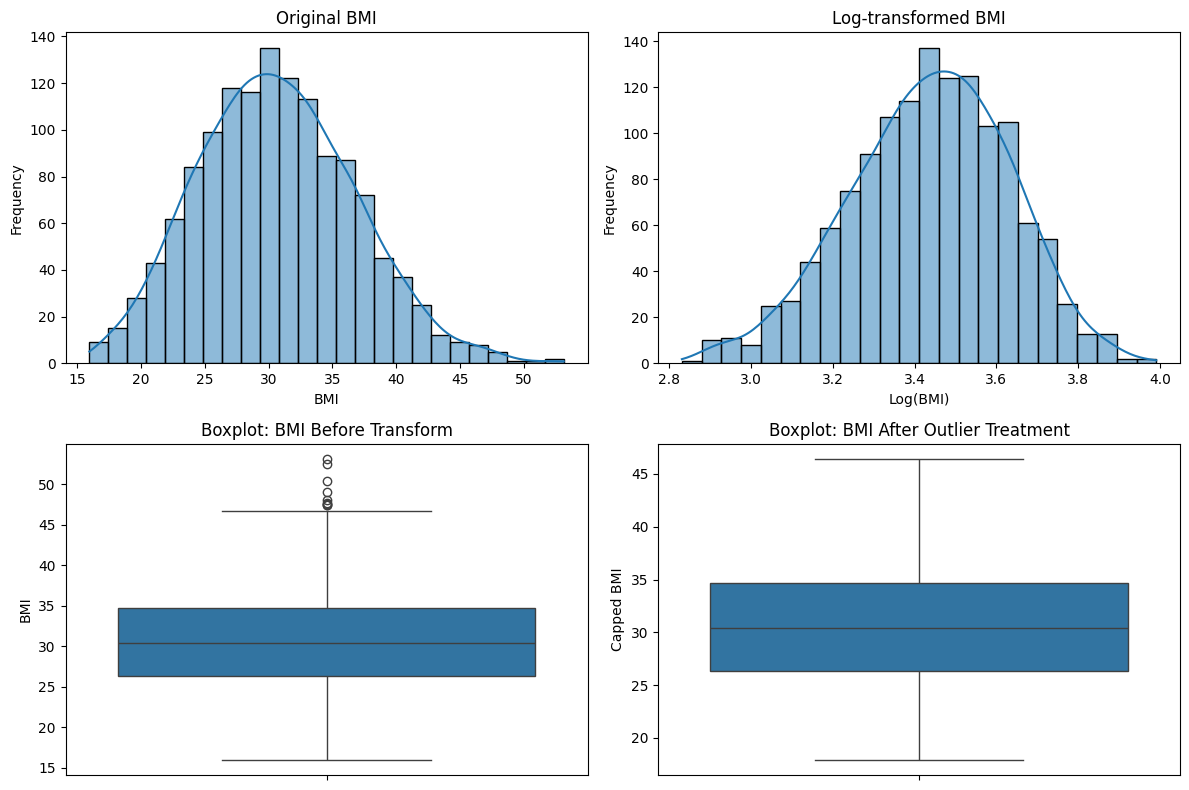

In [46]:
plt.figure(figsize=(10, 3)) 

# Create a single 2x2 grid for all plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # 2 rows, 2 columns

# Top-left: Original BMI histogram
sns.histplot(df['bmi'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Original BMI')
axes[0, 0].set_xlabel('BMI')
axes[0, 0].set_ylabel('Frequency')

# Top-right: Log-transformed BMI histogram
sns.histplot(df['bmi_log'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Log-transformed BMI')
axes[0, 1].set_xlabel('Log(BMI)')
axes[0, 1].set_ylabel('Frequency')

# Bottom-left: Boxplot before transformation
sns.boxplot(y=df["bmi"], ax=axes[1, 0])
axes[1, 0].set_title('Boxplot: BMI Before Transform')
axes[1, 0].set_ylabel('BMI')

# Bottom-right: Boxplot after outlier treatment
sns.boxplot(y=df['bmi_capped'], ax=axes[1, 1])
axes[1, 1].set_title('Boxplot: BMI After Outlier Treatment')
axes[1, 1].set_ylabel('Capped BMI')


plt.tight_layout() #Prevent Overlapping 
plt.show()

#### 6.4 Median Imputation
- Replace extreme `bmi` values with median 

In [47]:
median_bmi = df['bmi'].median()
mask = (df['bmi'] < low_bmi) | (df['bmi'] > high_bmi)
df['bmi_med_imp'] = df['bmi']
df.loc[mask, 'bmi_med_imp'] = median_bmi
print(df[['bmi','bmi_med_imp']].head())

      bmi  bmi_med_imp
0  27.900       27.900
1  33.770       33.770
2  33.000       33.000
3  22.705       22.705
4  28.880       28.880


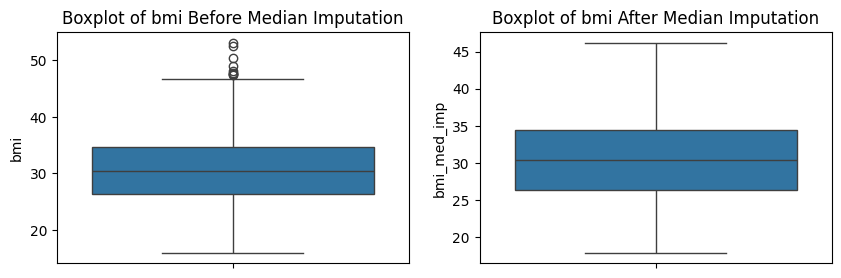

In [48]:
# Visualization of box plot before and after outlier treatment
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
sns.boxplot(data=df["bmi"])
plt.title('Boxplot of bmi Before Median Imputation')

plt.subplot(1, 2, 2)
sns.boxplot(data=df["bmi_med_imp"])
plt.title('Boxplot of bmi After Median Imputation')
plt.show()

#### 6.5 Z-Score Method
- Compute Z-scores  
- Remove rows with |Z| > 3  

##### Note(Why z > 3 ??)
In a normal distribution:

- About 68% of values lie within ±1σ
- About 95% lie within ±2σ
- About 99.7% lie within ±3σ

So, if a point has a z-score greater than 3 or less than -3, it's in the outer 0.3% of the distribution.
Only 0.15% of values are expected to lie above z = 3
Only 0.15% are expected to lie below z = -3

In [49]:
from scipy.stats import zscore

df['bmi_zscore'] = zscore(df['bmi'].fillna(df['bmi'].mean()))
df_z = df[df['bmi_zscore'].abs() <= 3]
print("Shape after Z-score filtering:", df_z.shape)

Shape after Z-score filtering: (1333, 14)


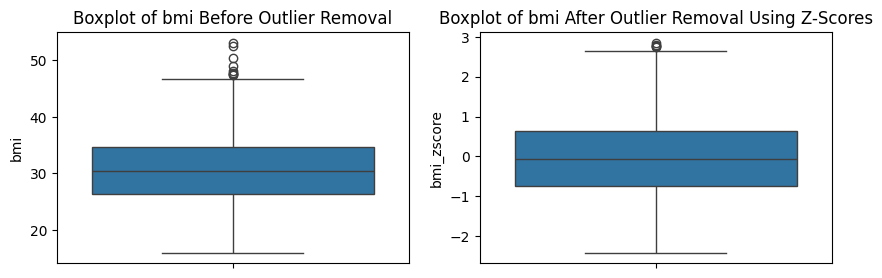

In [50]:
# Visualization of box plot before and after outlier treatment
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
sns.boxplot(data=df["bmi"])
plt.title('Boxplot of bmi Before Outlier Removal')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_z["bmi_zscore"])
plt.title('Boxplot of bmi After Outlier Removal Using Z-Scores')
plt.show()